# **Import Libraries**

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# **Load Data**

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# **Model Architecture**

In [9]:
class MulticlassCNN(nn.Module):
    def __init__(self):
        super(MulticlassCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [10]:
model = MulticlassCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# **Training Loop**

In [14]:
num_epochs = 15

for epoch in range(num_epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}] - Avg Loss: {running_loss / len(train_loader):.4f}")

Epoch [1/15] - Avg Loss: 0.6271
Epoch [2/15] - Avg Loss: 0.5594
Epoch [3/15] - Avg Loss: 0.4971
Epoch [4/15] - Avg Loss: 0.4466
Epoch [5/15] - Avg Loss: 0.3935
Epoch [6/15] - Avg Loss: 0.3470
Epoch [7/15] - Avg Loss: 0.3023
Epoch [8/15] - Avg Loss: 0.2675
Epoch [9/15] - Avg Loss: 0.2399
Epoch [10/15] - Avg Loss: 0.2076
Epoch [11/15] - Avg Loss: 0.1882
Epoch [12/15] - Avg Loss: 0.1702
Epoch [13/15] - Avg Loss: 0.1487
Epoch [14/15] - Avg Loss: 0.1361
Epoch [15/15] - Avg Loss: 0.1268


# **Test Accuracy**

In [15]:
correct = 0
total = 0
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\nOverall Test Accuracy: {100 * correct / total:.2f}%\n")


Overall Test Accuracy: 66.91%



# **Plot Results**

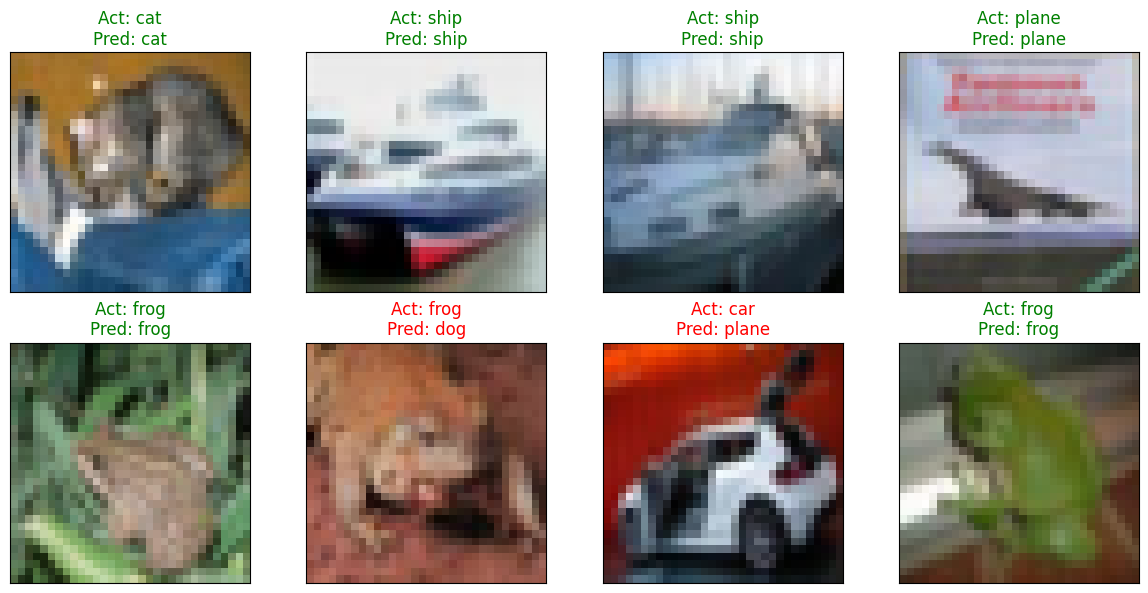

In [16]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

fig = plt.figure(figsize=(12, 6))

for i in range(8):
    ax = fig.add_subplot(2, 4, i+1, xticks=[], yticks=[])
    img = images[i] / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

    act_label = classes[labels[i]]
    pred_label = classes[predicted[i]]
    color = "green" if act_label == pred_label else "red"
    ax.set_title(f"Act: {act_label}\nPred: {pred_label}", color=color)

plt.tight_layout()
plt.show()